# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


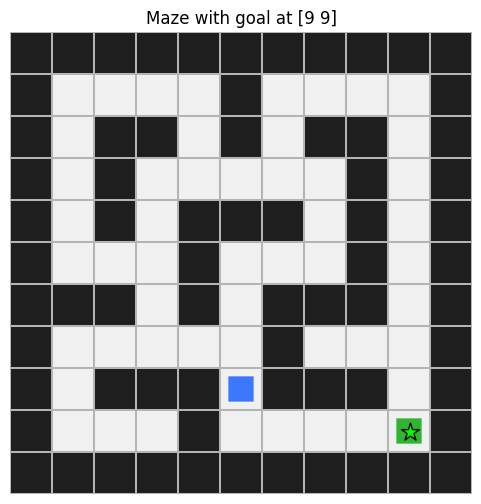

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

## Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(9, 9) -----

[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-49.963 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-49.963 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-43.525 | eval_len=437.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.962 | eval_return=-43.625 | eval_len=438.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.953 | eval_return=-49.863 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.998 | Loss=0.004| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factor

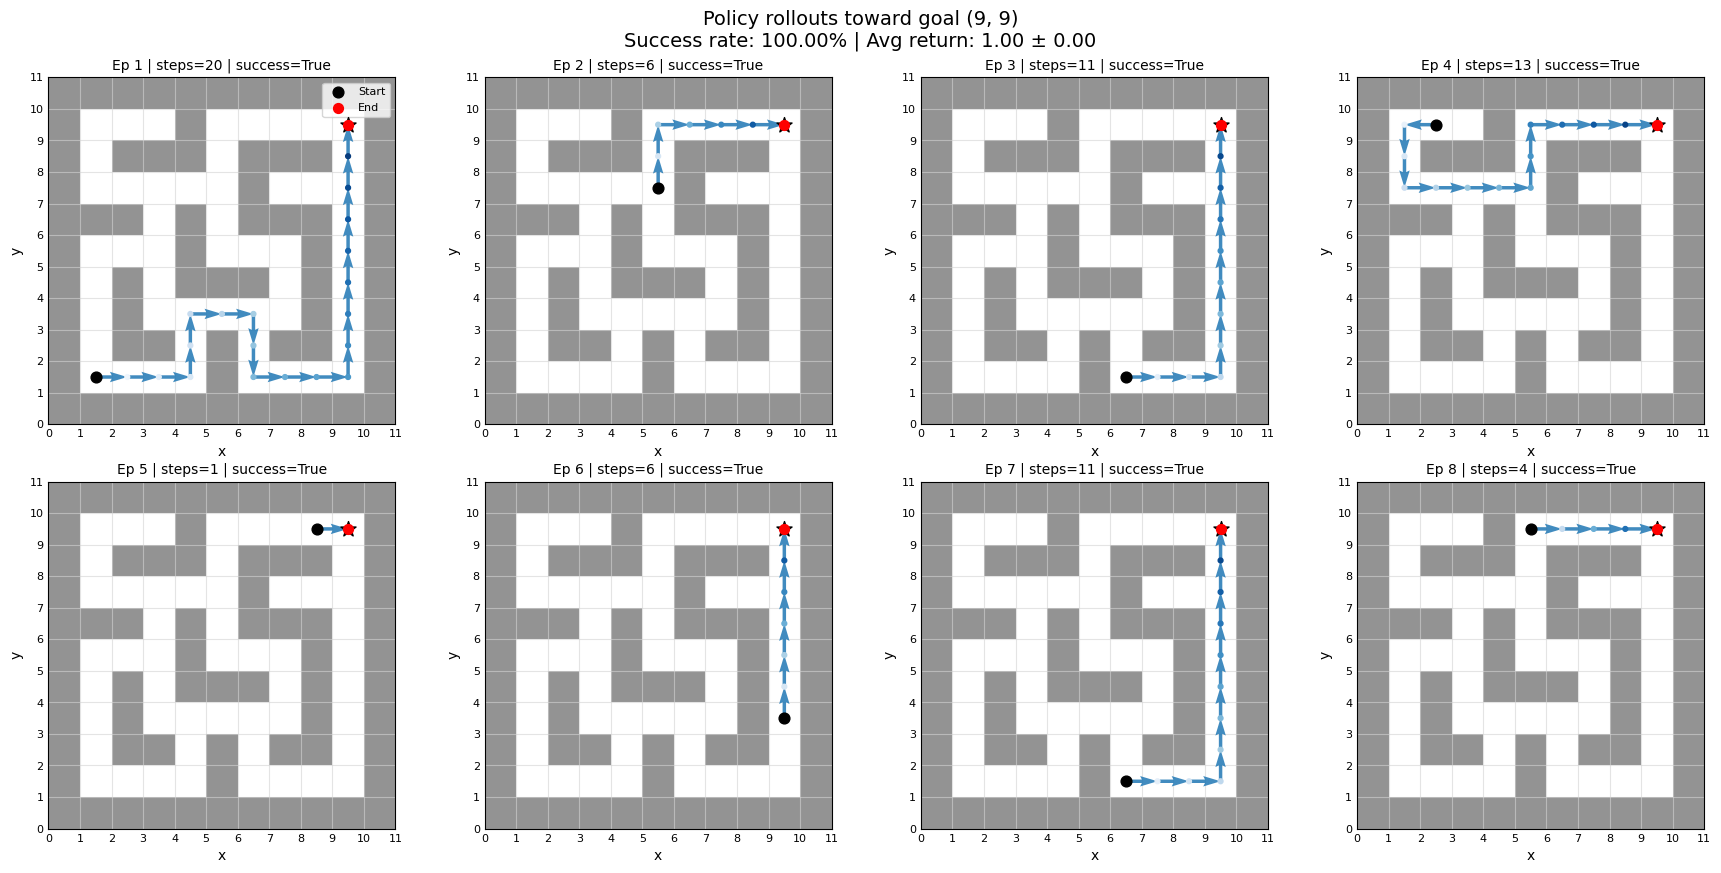

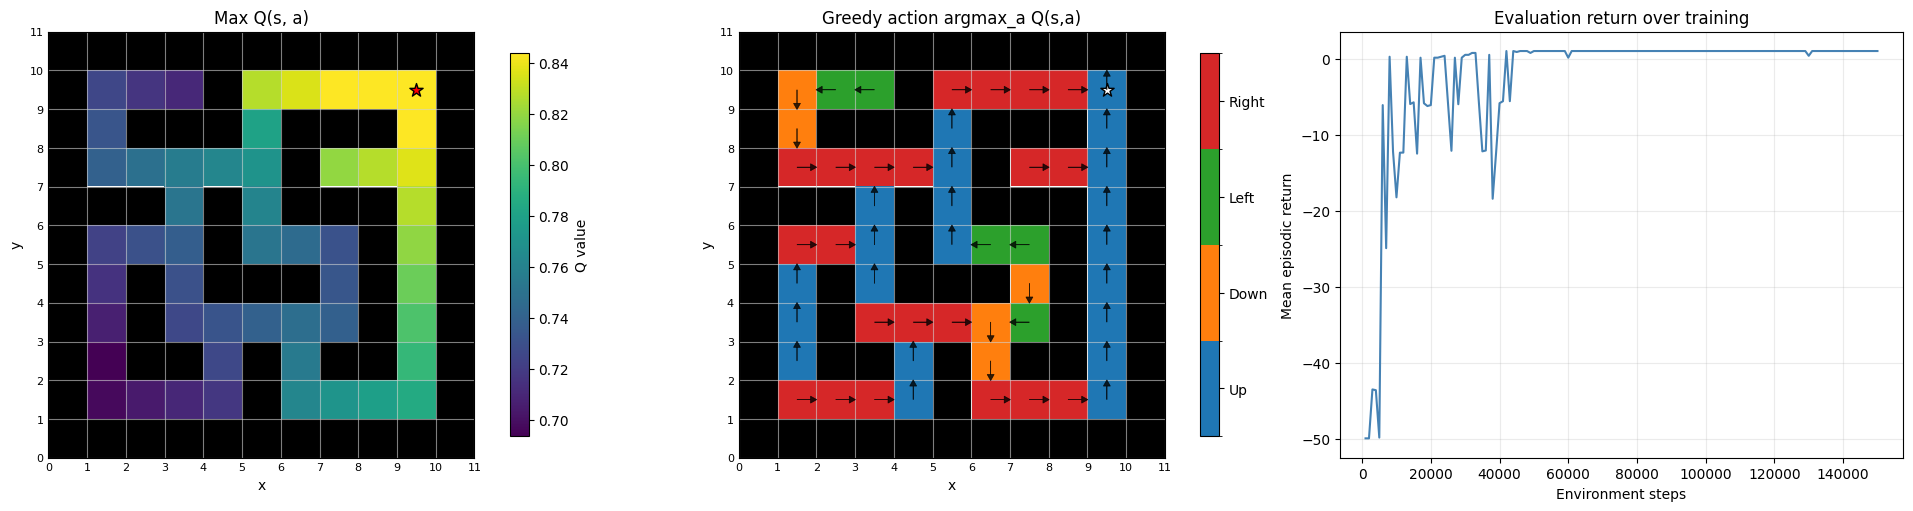

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.0599303 3.2896855 2.5437403 2.1268456 1.980538 ]
cumulative variance (first 5 dims): [0.35951936 0.5114838  0.60234505 0.6658643  0.720945  ]
cos(phi(s,a), psi): mean=0.7076, std=0.0669


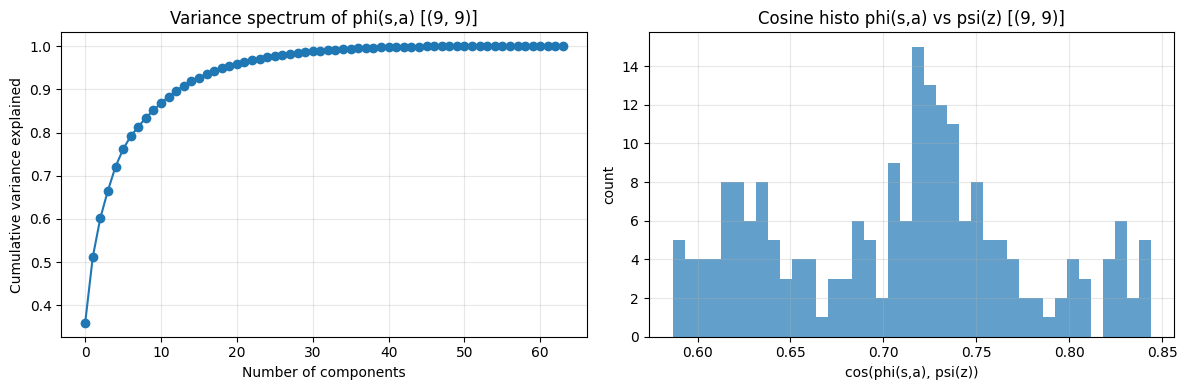


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000

----- seed=42, goal=(7, 7) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-48.950 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-49.525 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-49.063 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   4000 | eps=0.962 | eval_return=-49.125 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.0

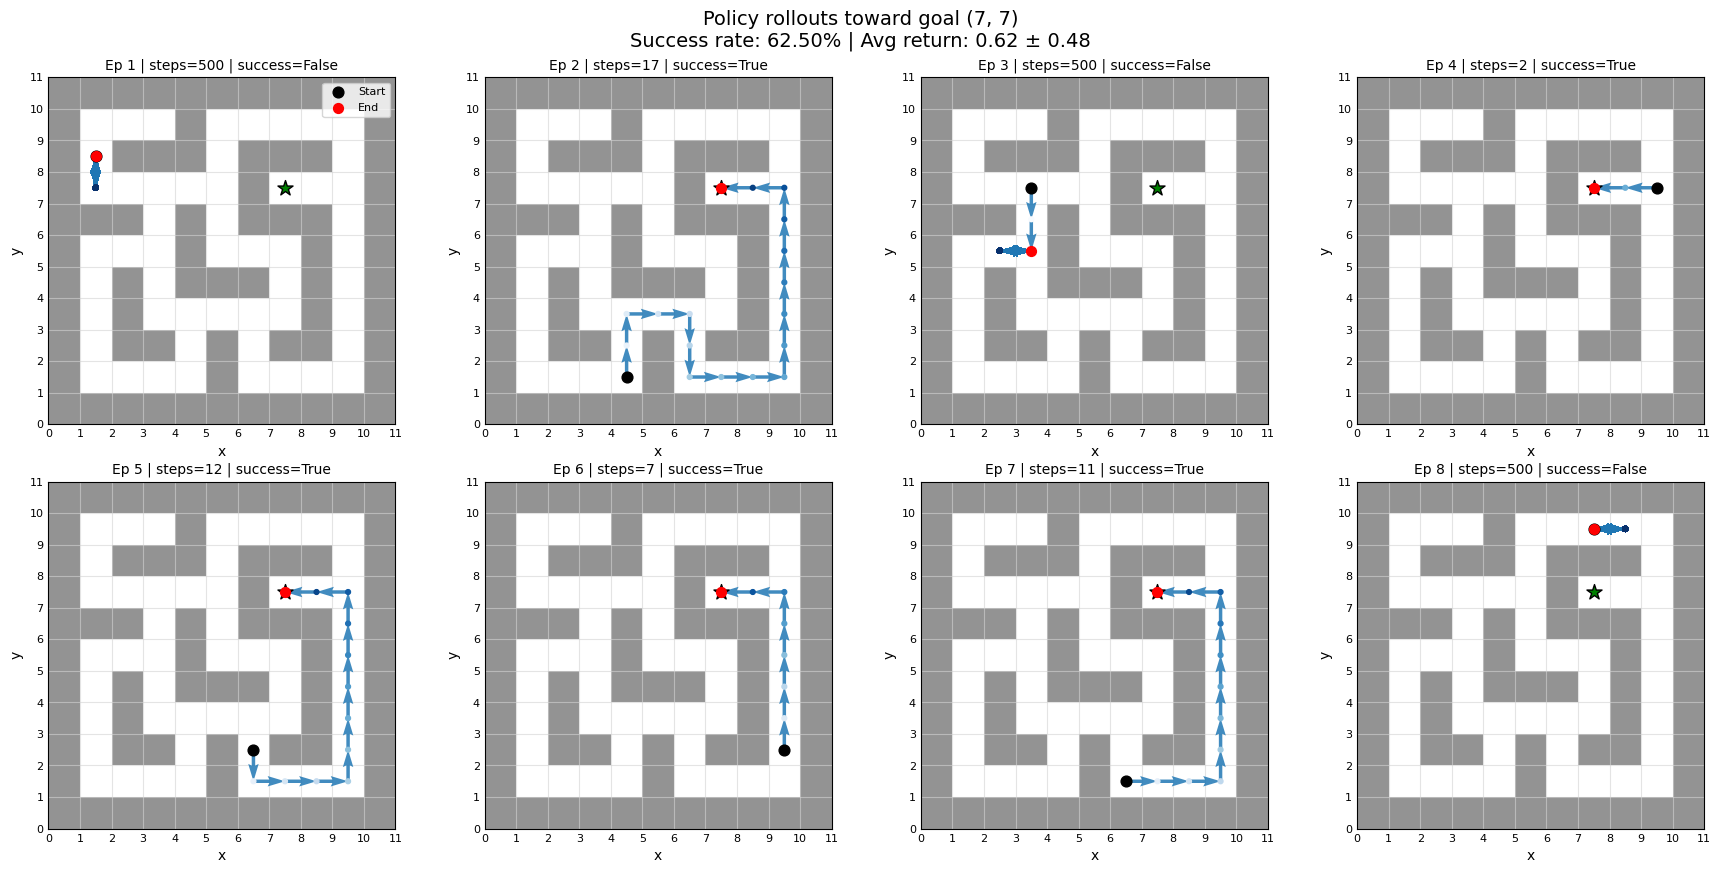

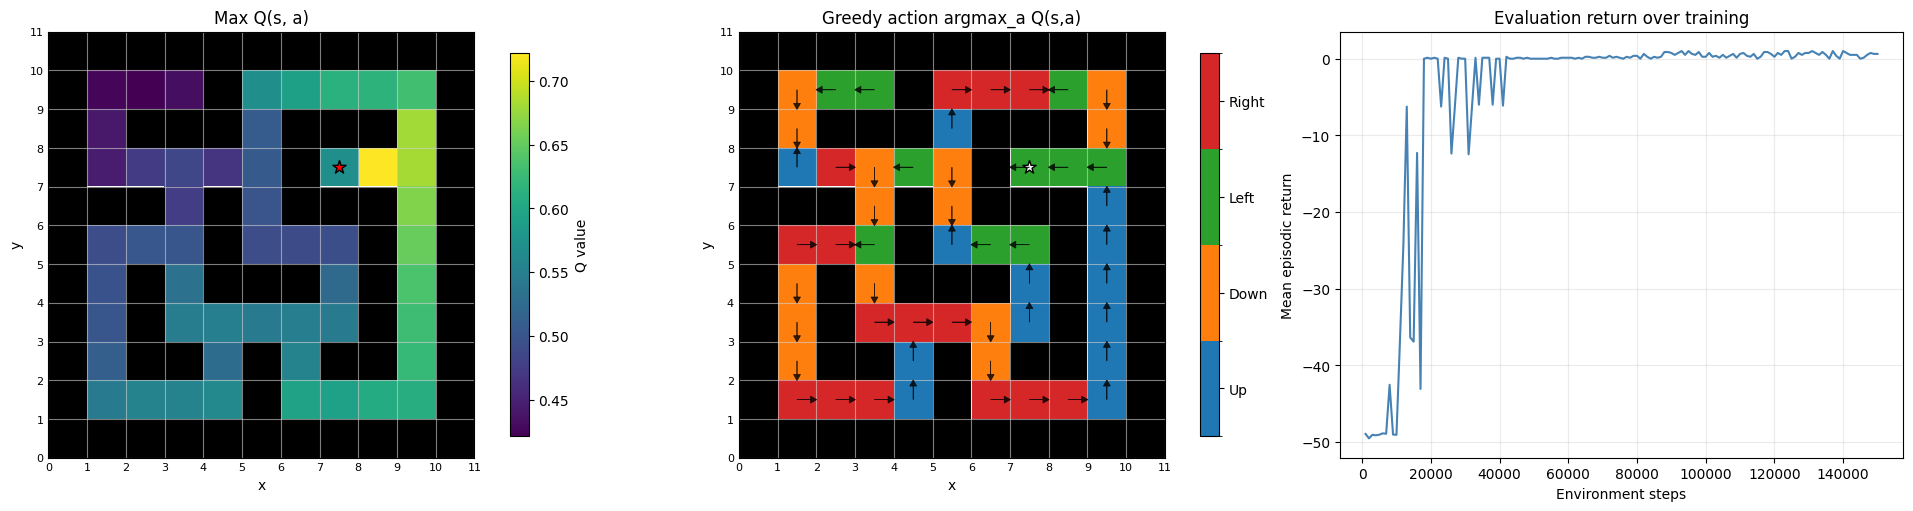

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.196934  3.52751   2.7291627 2.1945887 2.1680288]
cumulative variance (first 5 dims): [0.33273515 0.48603463 0.5777967  0.63713163 0.6950391 ]
cos(phi(s,a), psi): mean=0.4912, std=0.0853


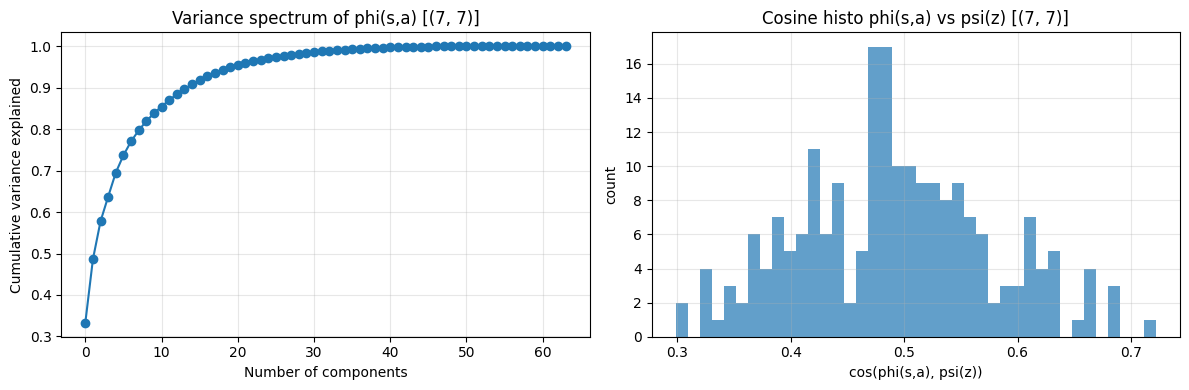


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)
  (9, 9)      1.000      0.828
  (7, 7)      0.828      1.000

Off-diagonal mean similarity: 0.828
Off-diagonal min similarity: 0.828
Off-diagonal max similarity: 0.828

----- seed=42, goal=(3, 5) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-12.488 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=0.000 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=0.125 | eval_len=437.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first 

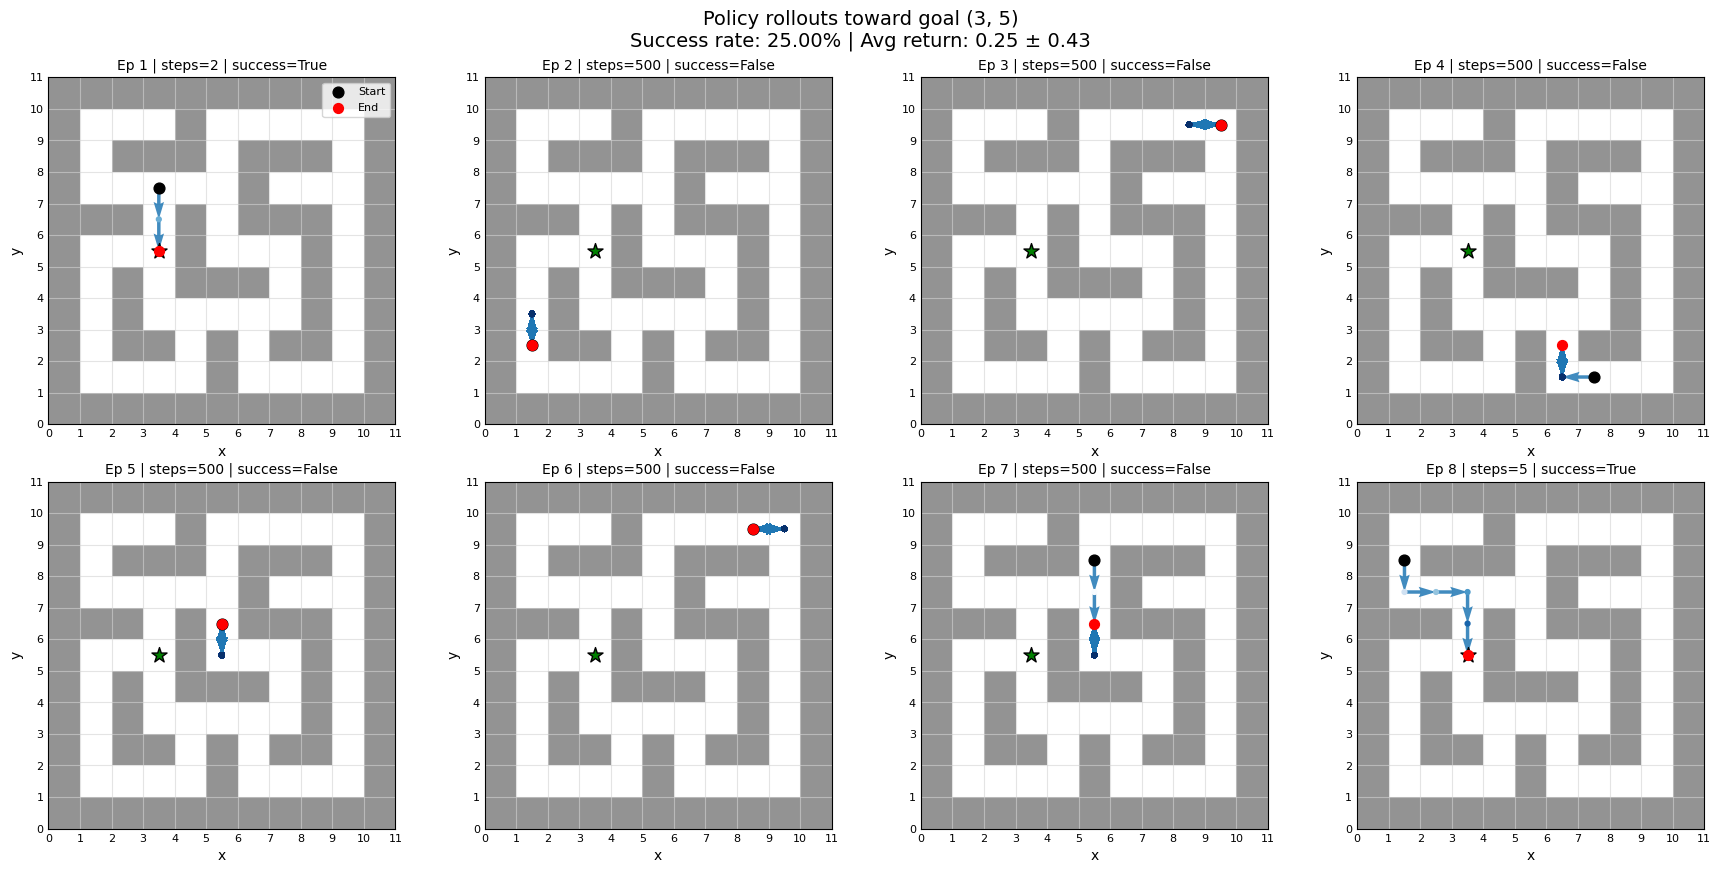

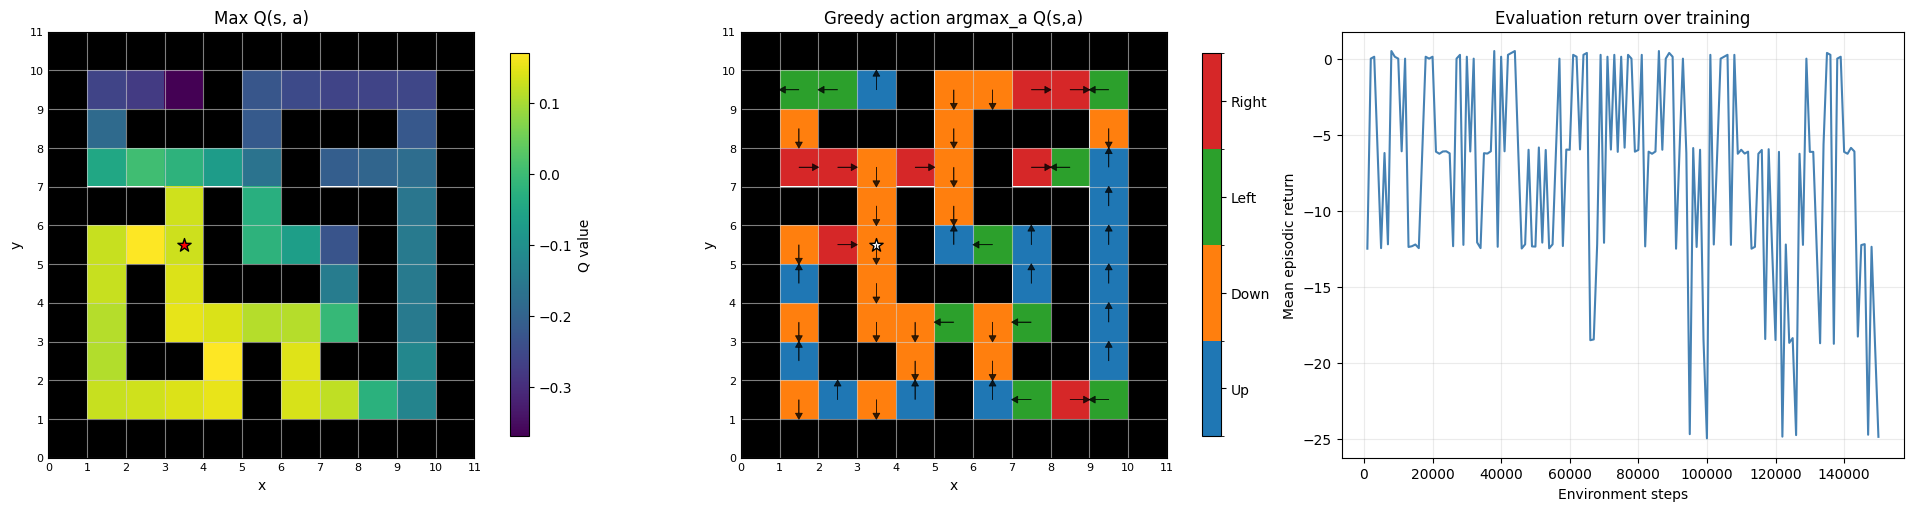

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.196879  3.5277169 2.7294252 2.1948195 2.168284 ]
cumulative variance (first 5 dims): [0.33269757 0.486001   0.5777723  0.6371143  0.69503003]
cos(phi(s,a), psi): mean=-0.0944, std=0.1718


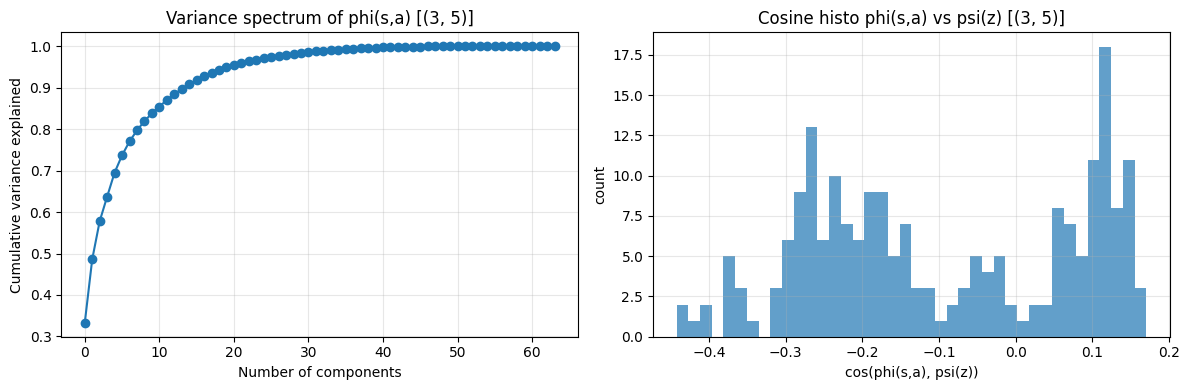


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.828      0.087
  (7, 7)      0.828      1.000      0.167
  (3, 5)      0.087      0.167      1.000

Off-diagonal mean similarity: 0.361
Off-diagonal min similarity: 0.087
Off-diagonal max similarity: 0.828

----- seed=42, goal=(3, 9) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=-12.488 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-6.250 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=0.972 | eval_return=-12.500 | eval_len=500.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000

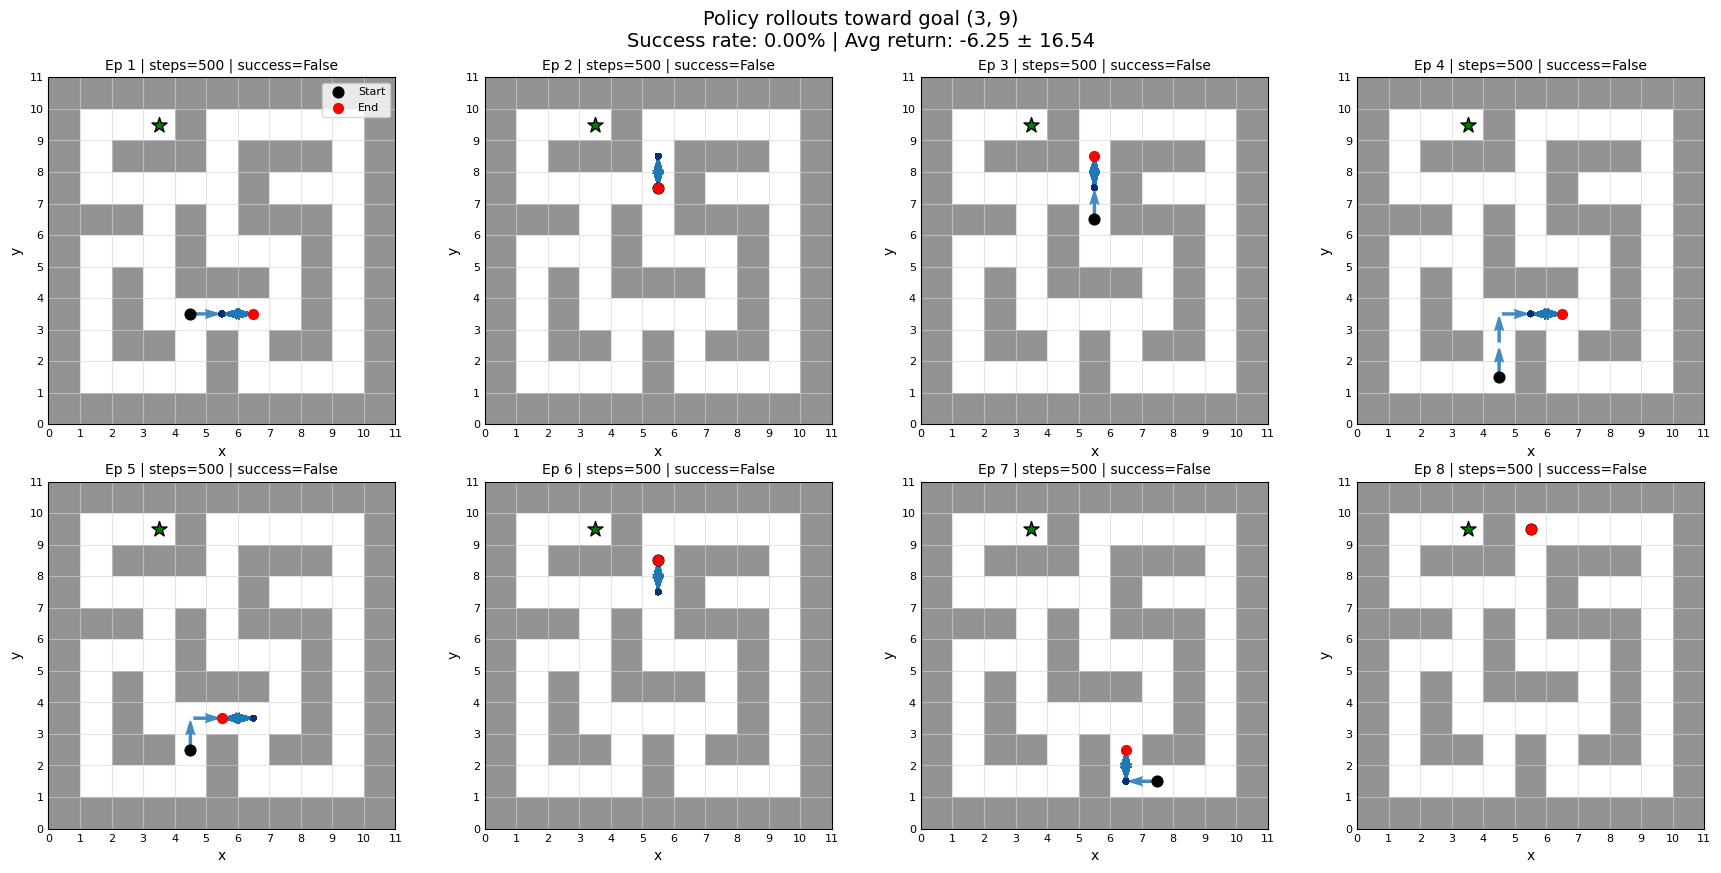

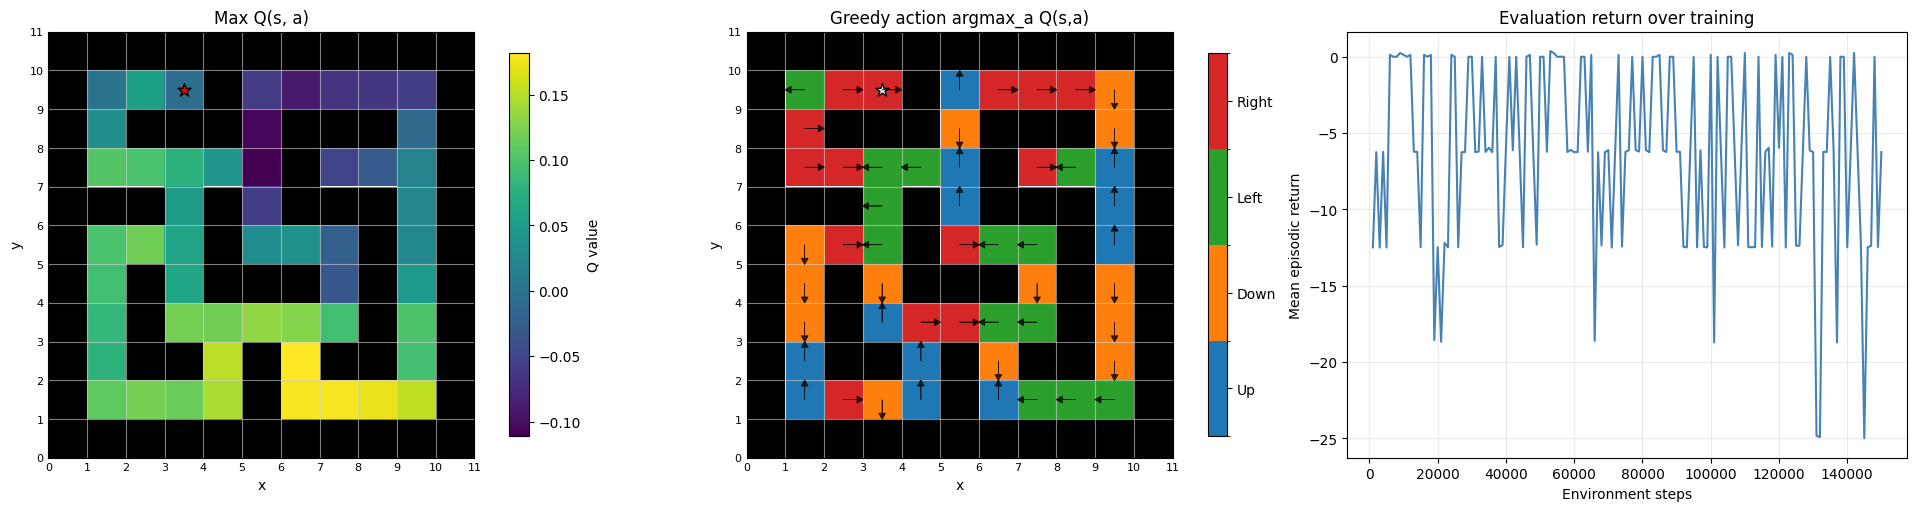

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.197069  3.527331  2.7291307 2.194772  2.168203 ]
cumulative variance (first 5 dims): [0.33276224 0.48605072 0.5778133  0.63715994 0.6950784 ]
cos(phi(s,a), psi): mean=0.0121, std=0.0833


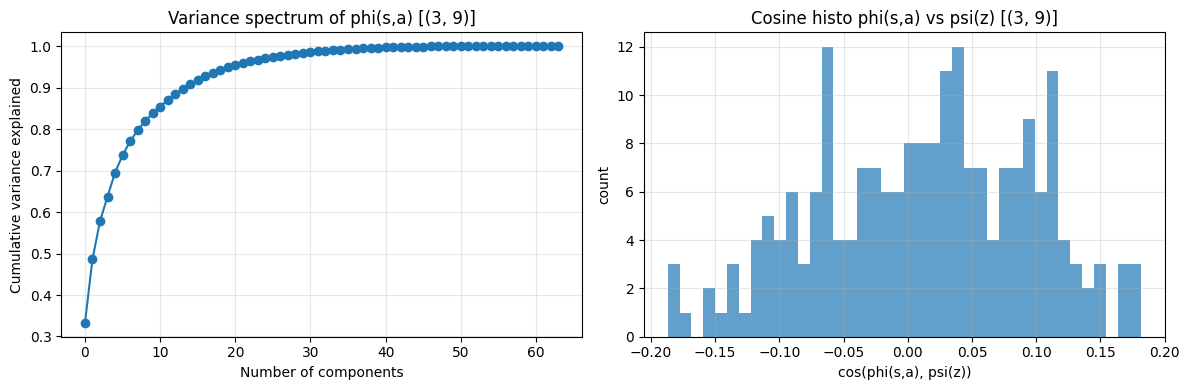


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.828      0.087      0.199
  (7, 7)      0.828      1.000      0.167      0.157
  (3, 5)      0.087      0.167      1.000      0.509
  (3, 9)      0.199      0.157      0.509      1.000

Off-diagonal mean similarity: 0.325
Off-diagonal min similarity: 0.087
Off-diagonal max similarity: 0.828

----- seed=42, goal=(5, 5) -----

Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   1000 | eps=0.991 | eval_return=0.375 | eval_len=313.1| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   2000 | eps=0.981 | eval_return=-6.113 | eval_len=438.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
Mean squared deltas (first few): [0.0, 0.0, 0.0, 0.0]
[DQN-factorised] step=   3000 | eps=

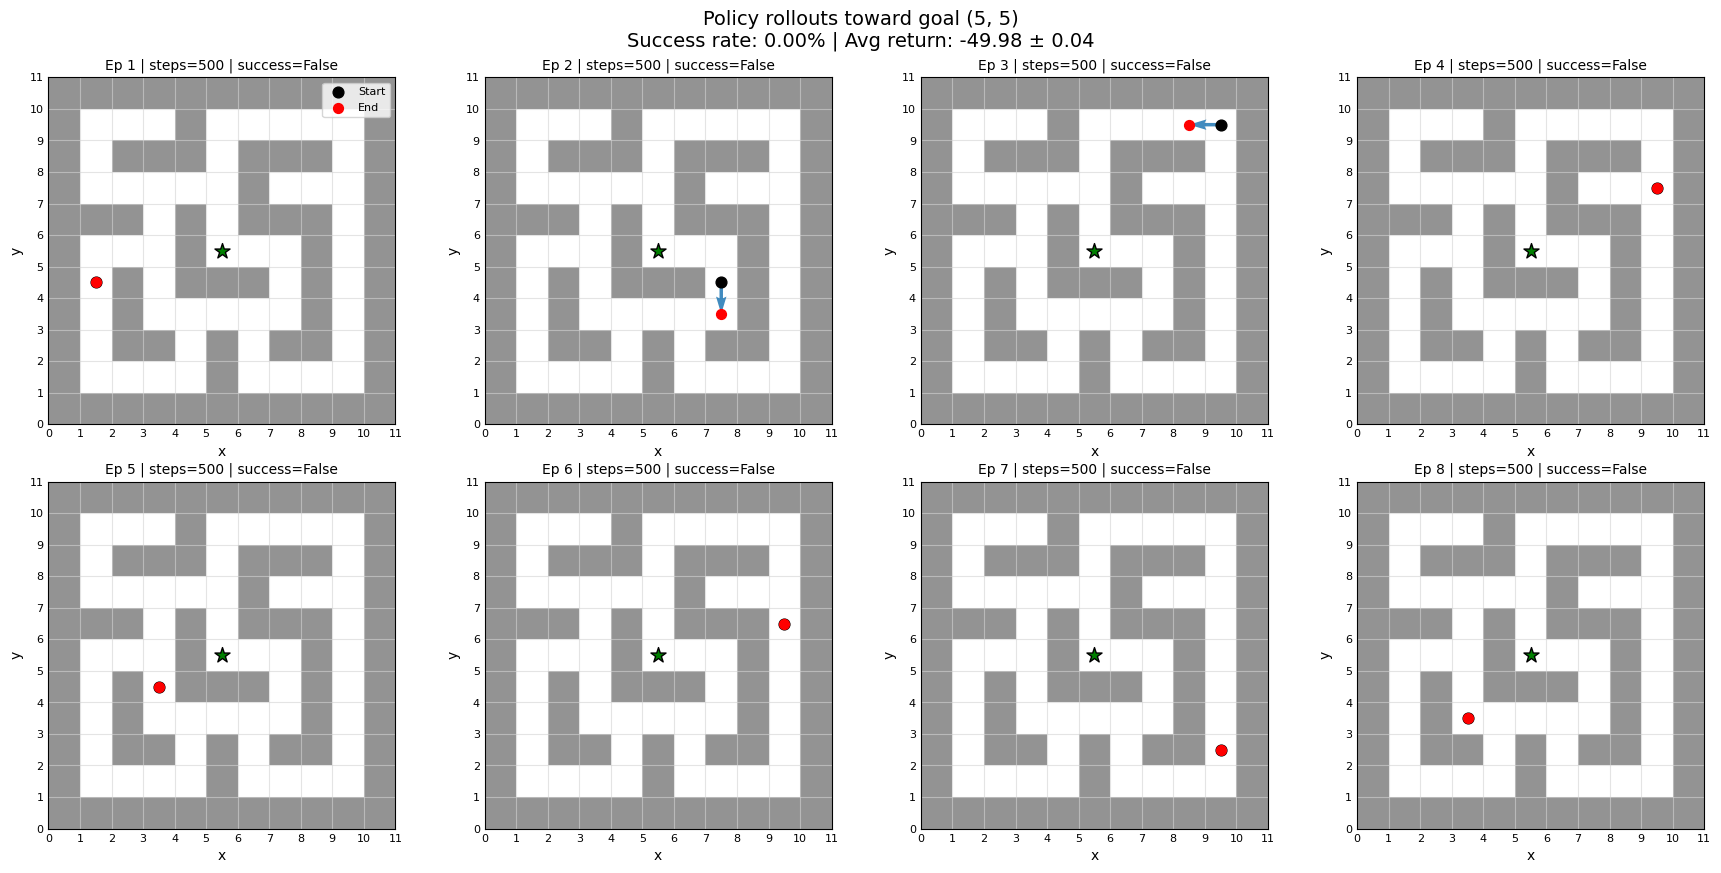

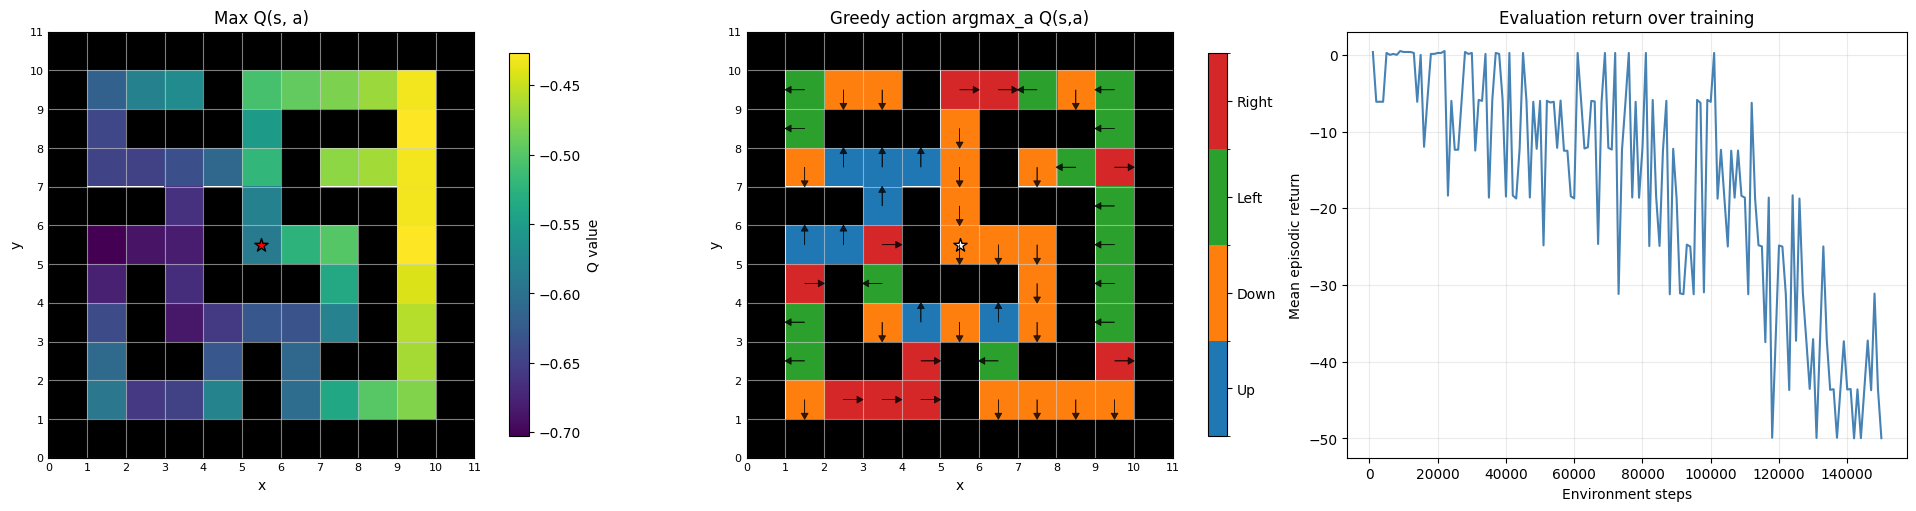

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.197132  3.5275774 2.729111  2.1947384 2.168118 ]
cumulative variance (first 5 dims): [0.33276543 0.48607308 0.577833   0.63717693 0.69509   ]
cos(phi(s,a), psi): mean=-0.6083, std=0.0899


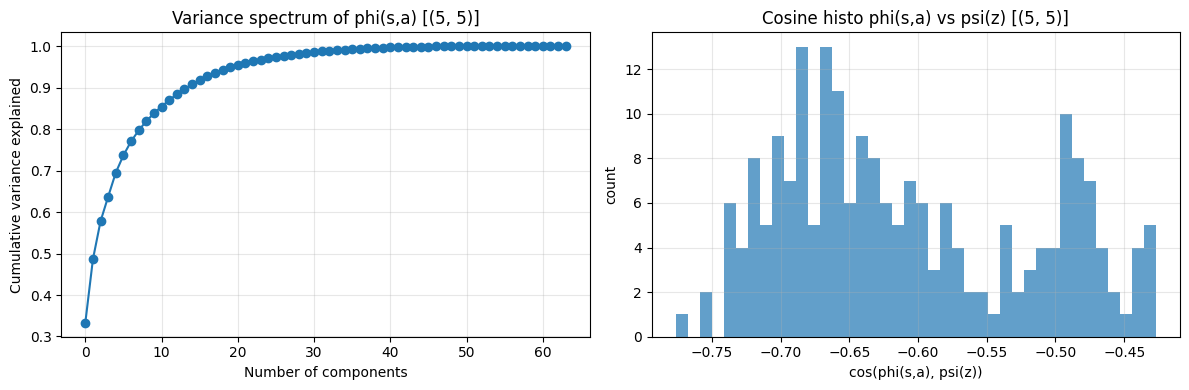


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.828      0.087      0.199     -0.571
  (7, 7)      0.828      1.000      0.167      0.157     -0.365
  (3, 5)      0.087      0.167      1.000      0.509      0.209
  (3, 9)      0.199      0.157      0.509      1.000      0.104
  (5, 5)     -0.571     -0.365      0.209      0.104      1.000

Off-diagonal mean similarity: 0.132
Off-diagonal min similarity: -0.571
Off-diagonal max similarity: 0.828


In [3]:
SEEDS = [42]
GOALS = [(9, 9), (7, 7), (3, 5), (3, 9), (5, 5)]
BUFFER_CAPACITY = 100000
LR = float(1e-3)

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)  # your helper

    # Create env to get obs_dim, num_actions once
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # One network per seed, reused across goals
    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    # Per-seed task embedding memory (for repulsion)
    seed_task_embedding_memory = []
    seen_goal_labels = []
    prev_goal = None
    prev_buffer = None
    prev_q_net = None
    prev_q_target = None
    cumulative_fisher = None
    prev_reference_params = None

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        if goal_idx == 0:
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)
            q_target.load_state_dict(q_net.state_dict())
            for p in q_net.parameters():
                p.requires_grad_(True)
            trainable_params = None  # let dqn_train create its usual optimizer
            regulariser = None
            fisher_for_this_goal = None
            reference_for_this_goal = None
        else:
            if prev_q_net is None or prev_q_target is None:
                raise ValueError("Previous Q-networks are not available for transfer learning.")
            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)
            q_target.load_state_dict(q_net.state_dict())
            fisher_for_this_goal = cumulative_fisher
            reference_for_this_goal = prev_reference_params

            for p in q_net.parameters():
                p.requires_grad_(True)
            # Subsequent goals: reuse phi, train only psi (and optionally last phi layer)
            # for p in q_net.sa_encoder.parameters():
            #     p.requires_grad_(False)
            # for p in q_net.goal_encoder.parameters():
            #     p.requires_grad_(True)

            # # If you want psi + last phi layer instead of only psi:
            # last_layer = list(q_net.sa_encoder.children())[-1]
            # for p in last_layer.parameters():
            #     p.requires_grad_(True)

            trainable_params = [p for p in q_net.parameters() if p.requires_grad]
            regulariser = "repulsion"  # or None if you don’t want repulsion here
            # regulariser = None

        # Train on this goal, reusing q_net weights from previous goals
        (
        q_network,
        q_target_network,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
        )= dqn_train(
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            obs_dim=obs_dim,
            buffer_capacity=BUFFER_CAPACITY,
            lr=LR,
            goal=goal,
            device=DEVICE,
            embedding_memory=seed_task_embedding_memory,  # previous task embeddings in this seed
            regulariser=regulariser,
            reg_alpha=1,          # your choice 
            params=trainable_params, # None for full training, list for transfer mode
            reference_params=reference_for_this_goal,
            fisher_diag=fisher_for_this_goal,
            sa_reg_prefix_filter="sa_encoder",
            make_env=make_env
        )
        visualise_q_table(goal, q_network, eval_returns=eval_returns, device=DEVICE, make_env=make_env)
        visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)
        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

        current_reference = snapshot_named_parameters(q_network, prefix_filter="sa_encoder")
        current_fisher = estimate_fisher_diag(
            model=q_network,
            target_model=q_target_network,
            replay_buffer=buffer,
            goal=goal,
            num_actions=num_actions,
            device=DEVICE,
            gamma=0.99,
            batch_size=256,
            n_batches=64,
            prefix_filter="sa_encoder",
        )

        # Online/cumulative Fisher: F^{(1..t)} = F^{(1..t-1)} + F^{(t)}
        if cumulative_fisher is None:
            cumulative_fisher = current_fisher
        else:
            for name, F_t in current_fisher.items():
                if name in cumulative_fisher:
                    cumulative_fisher[name] = cumulative_fisher[name] + F_t
                else:
                    cumulative_fisher[name] = F_t.clone()

        # Anchor params become the latest task optimum theta_t^*
        prev_reference_params = current_reference
        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)

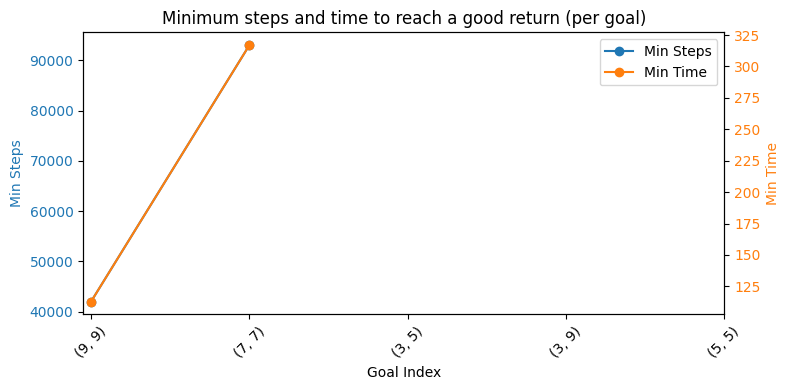

In [4]:
goals = list(overall_results.keys())

min_steps_per_goal = []
min_time_per_goal = []
used_goals = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.array(steps_raw).flatten()
    time_arr  = np.array(time_raw).flatten()

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    min_steps_per_goal.append(steps_arr.min())
    min_time_per_goal.append(time_arr.min())
    used_goals.append(goal)

if not min_steps_per_goal:
    raise ValueError("No goals with non-empty min_steps/min_time found.")

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
line1 = ax1.plot(
    x, min_steps_per_goal,
    label="Min Steps",
    color="tab:blue",
    marker="o",
)
ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
line2 = ax2.plot(
    x, min_time_per_goal,
    label="Min Time",
    color="tab:orange",
    marker="o",
)
ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
plt.show()

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

(9, 9) cos(old, final) = -0.5372109413146973
(7, 7) cos(old, final) = -0.37386736273765564
(3, 5) cos(old, final) = 0.48013824224472046
(3, 9) cos(old, final) = 0.8764550685882568
(5, 5) cos(old, final) = 1.0


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/src/visualisations.py:1052: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  task_embedding = torch.tensor(task_embedding, dtype=torch.float32, device=device)


Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 3 steps | return: 1.00 | reached goal: True
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 1 steps | return: 1.00 | reached goal: True
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 25.00% over 8 episodes
Average return: 0.25 ± 0.43


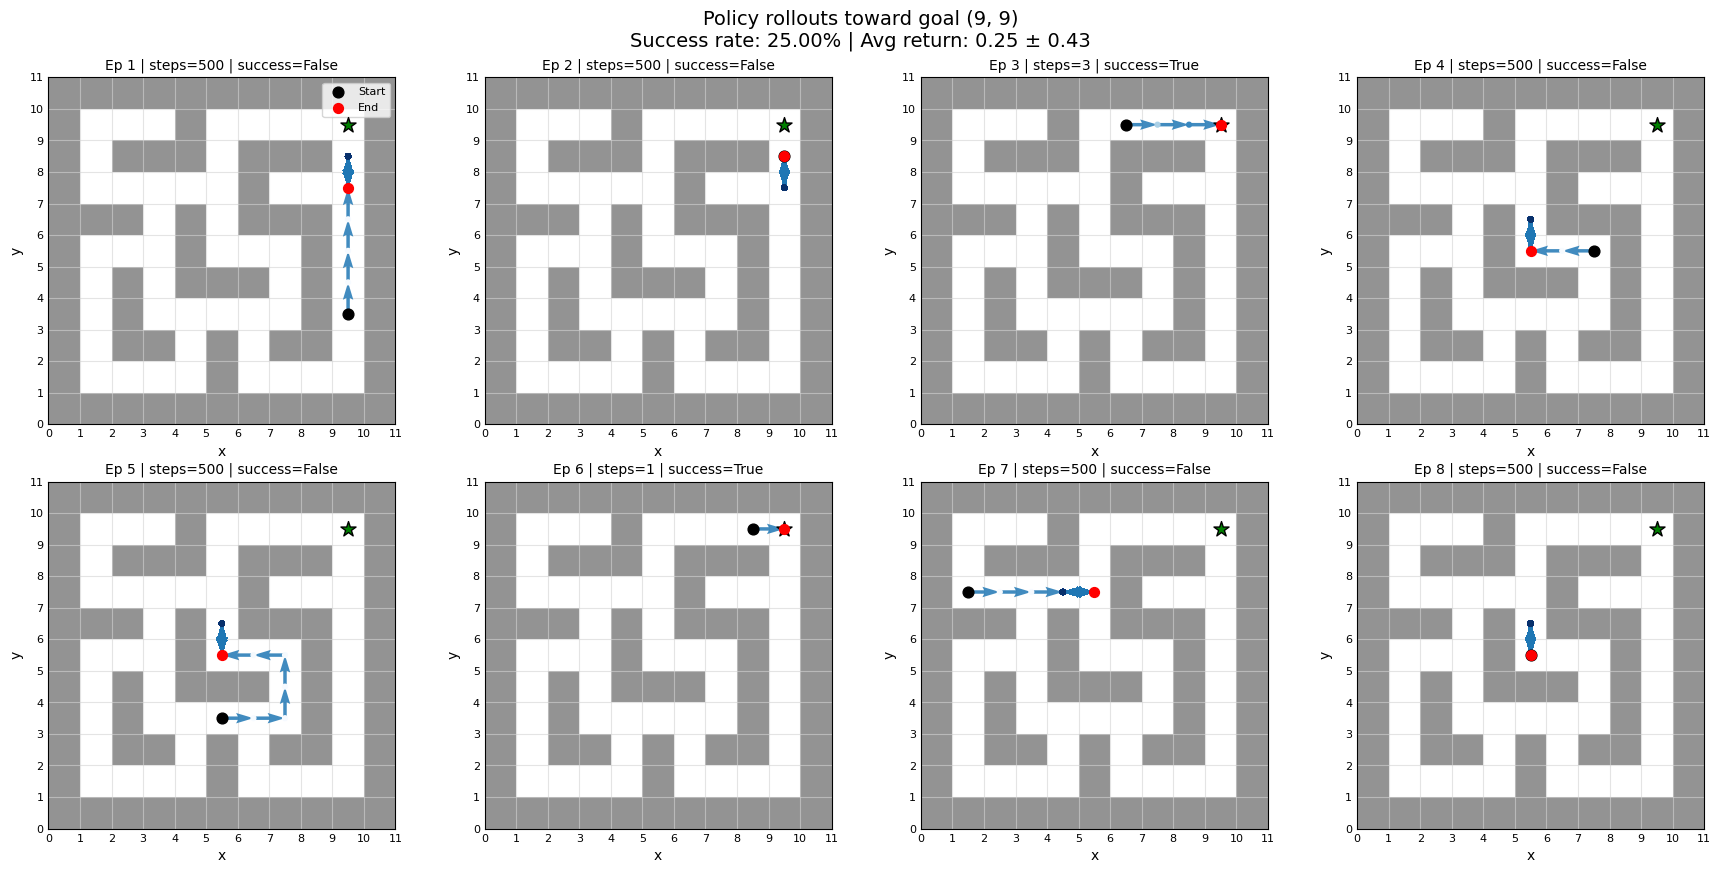

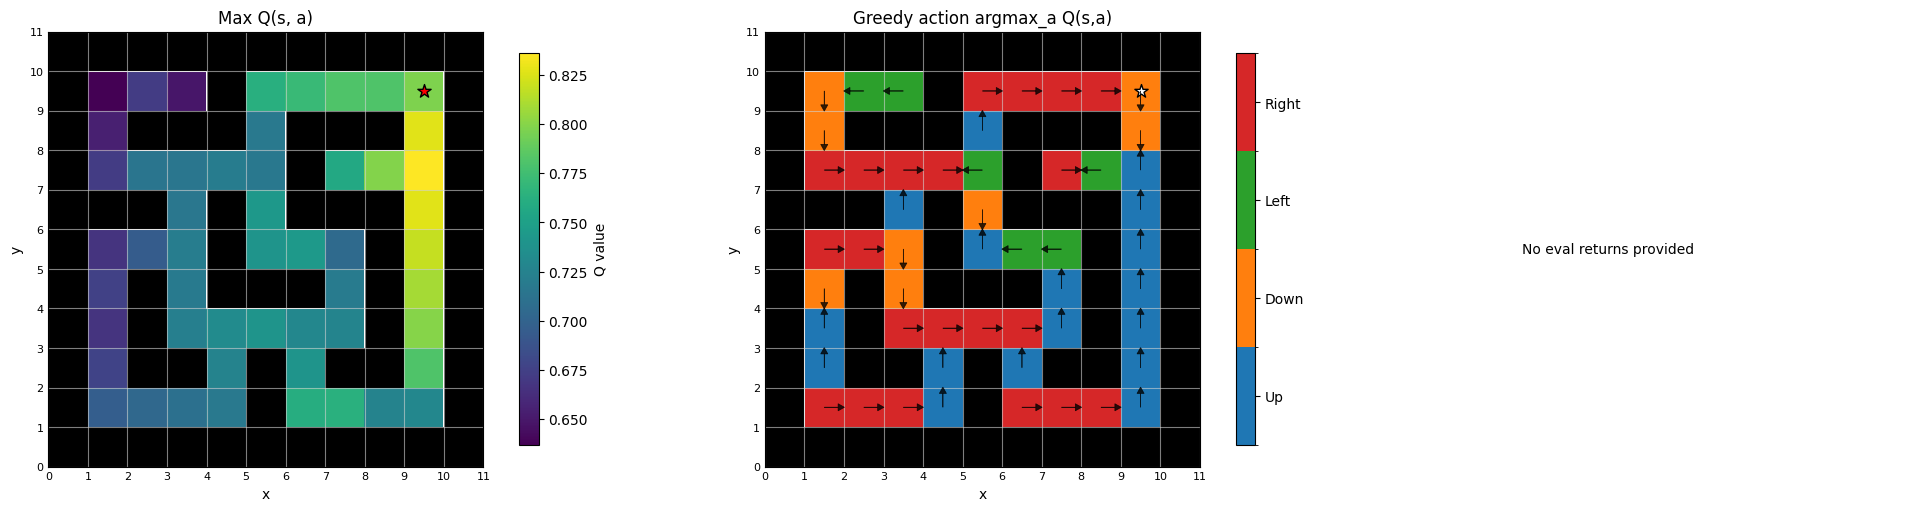

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.197132  3.5275774 2.729111  2.1947384 2.168118 ]
cumulative variance (first 5 dims): [0.33276543 0.48607308 0.577833   0.63717693 0.69509   ]
cos(phi(s,a), psi): mean=-0.5857, std=0.0952


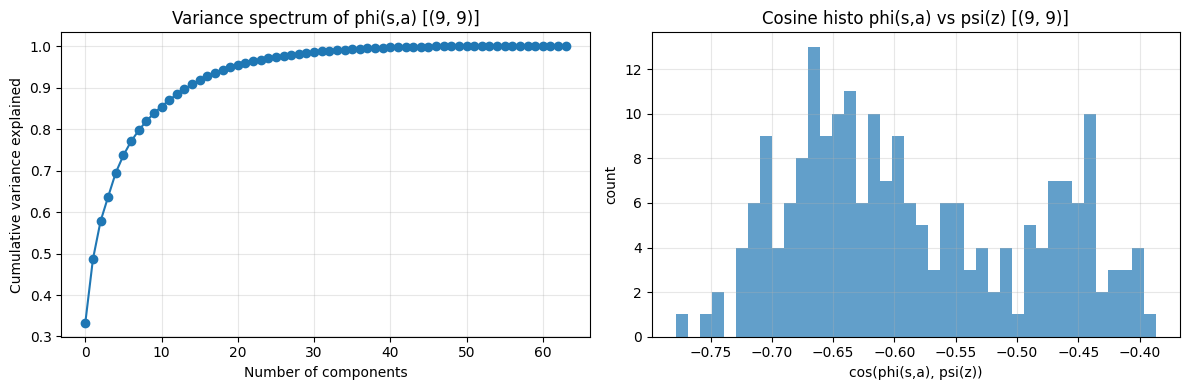

Episode 1: 500 steps | return: -50.00 | reached goal: False
Episode 2: 500 steps | return: -49.70 | reached goal: False
Episode 3: 500 steps | return: -50.00 | reached goal: False
Episode 4: 500 steps | return: -50.00 | reached goal: False
Episode 5: 500 steps | return: -50.00 | reached goal: False
Episode 6: 500 steps | return: -50.00 | reached goal: False
Episode 7: 500 steps | return: -49.90 | reached goal: False
Episode 8: 500 steps | return: -50.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: -49.95 ± 0.10


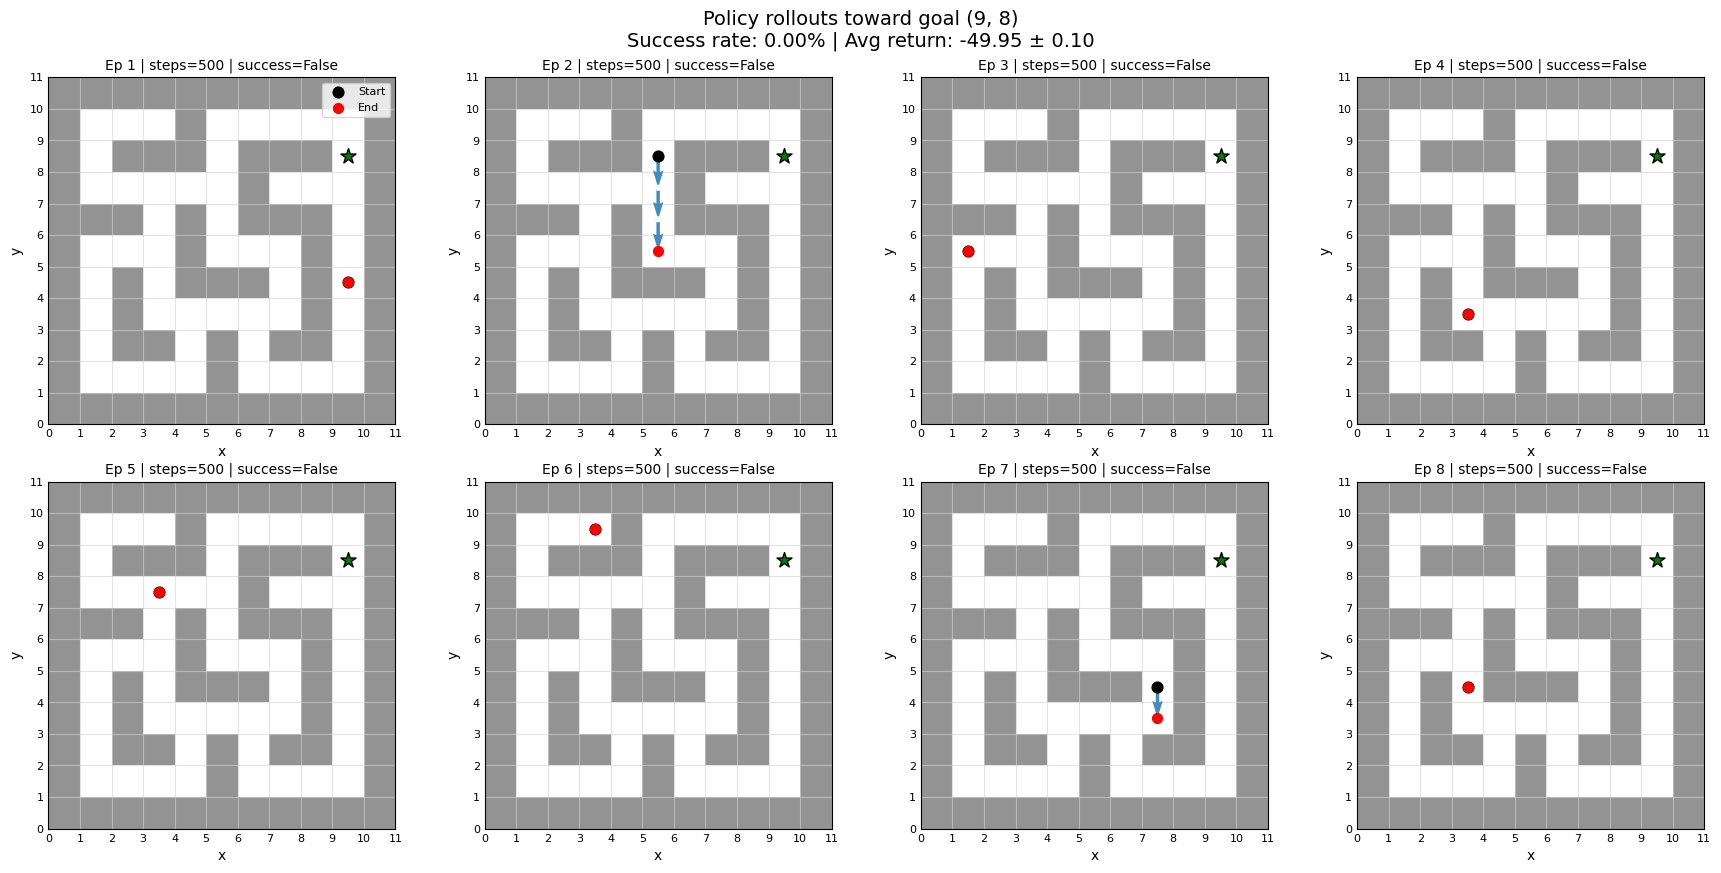

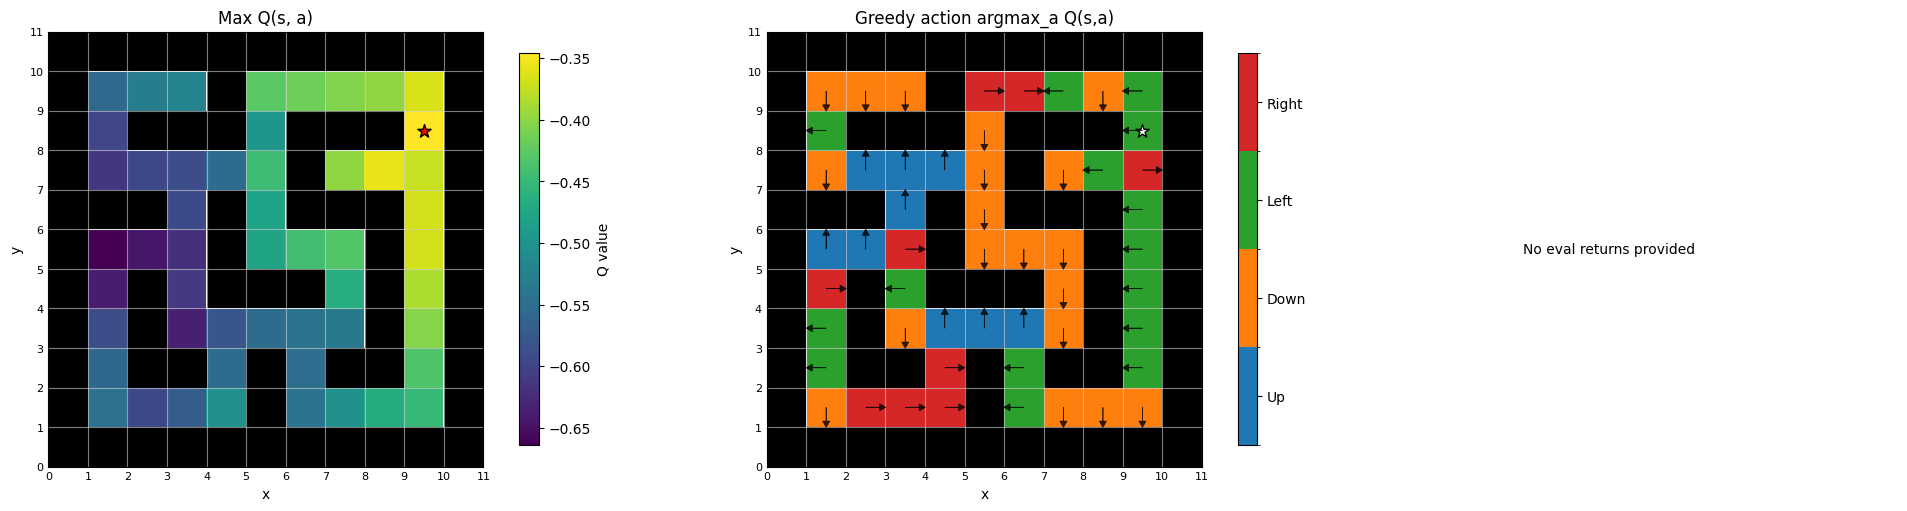

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.197132  3.5275774 2.729111  2.1947384 2.168118 ]
cumulative variance (first 5 dims): [0.33276543 0.48607308 0.577833   0.63717693 0.69509   ]
cos(phi(s,a), psi): mean=-0.5430, std=0.0951


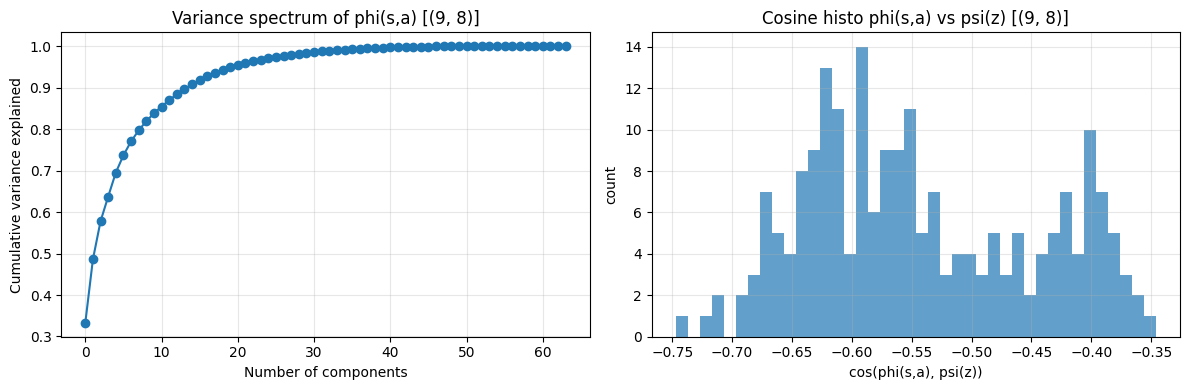

Episode 1: 500 steps | return: -49.80 | reached goal: False
Episode 2: 500 steps | return: -49.90 | reached goal: False
Episode 3: 500 steps | return: -49.80 | reached goal: False
Episode 4: 500 steps | return: -50.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: -50.00 | reached goal: False
Episode 7: 500 steps | return: -49.90 | reached goal: False
Episode 8: 500 steps | return: -49.90 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: -43.66 ± 16.50


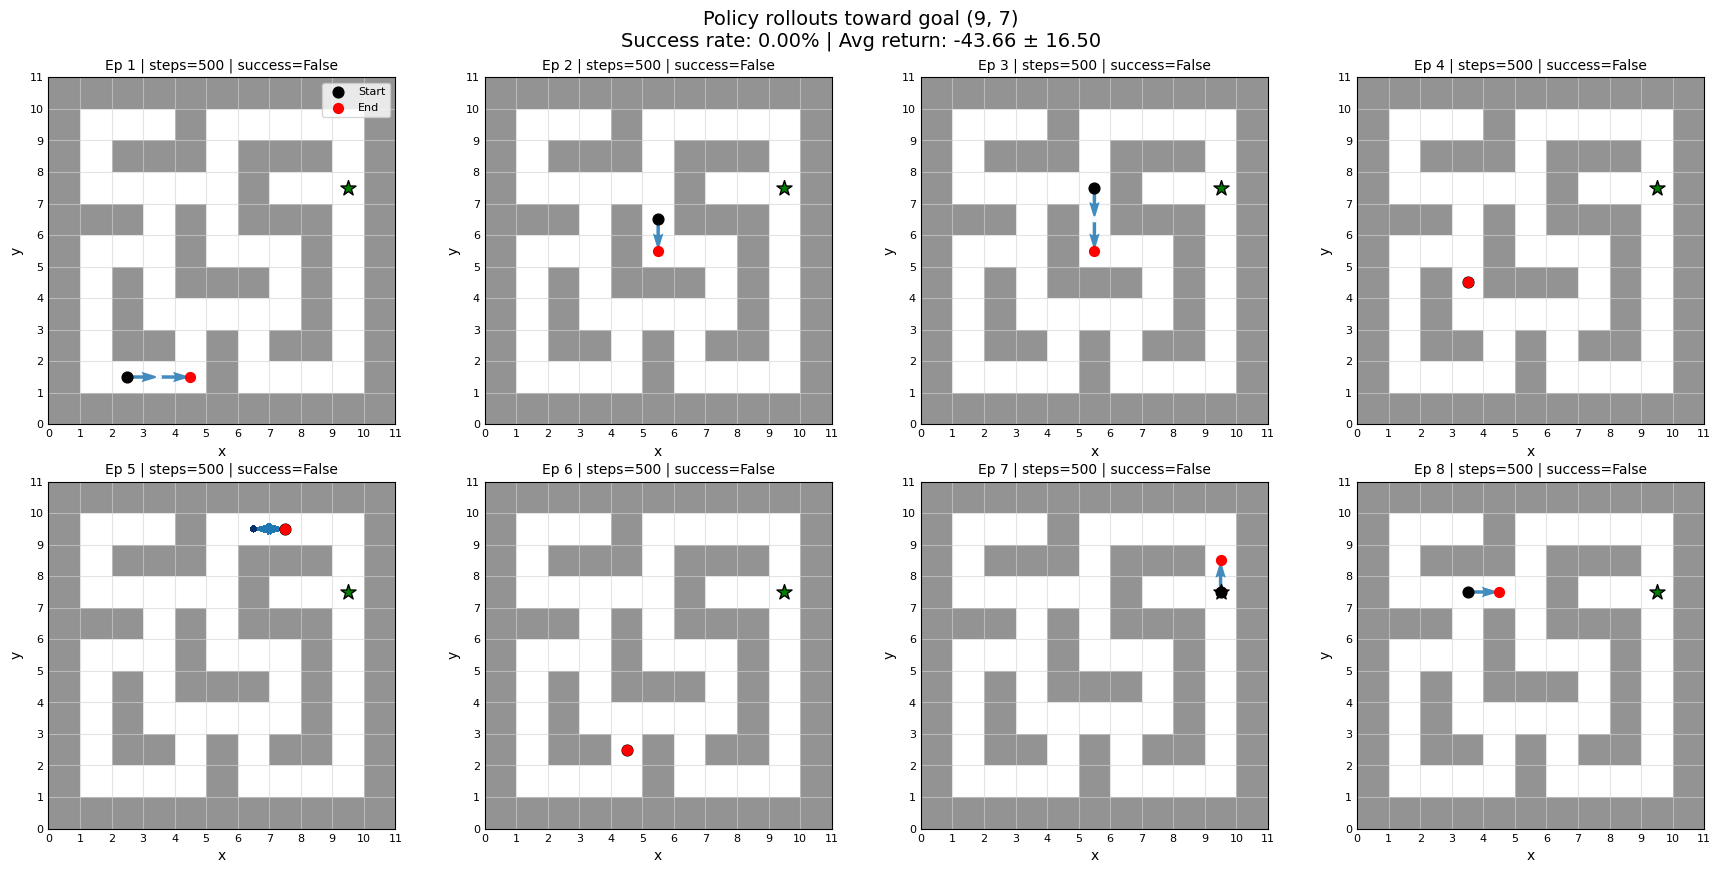

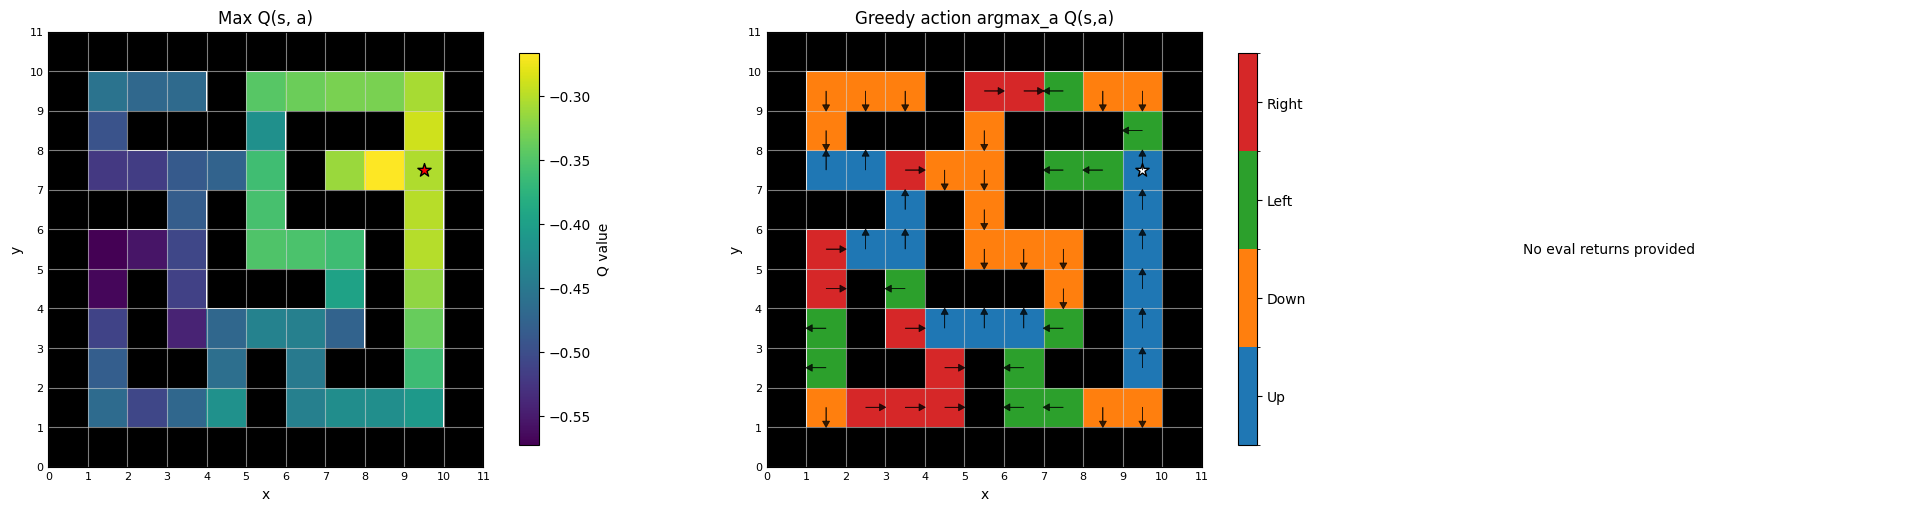

states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.197132  3.5275774 2.729111  2.1947384 2.168118 ]
cumulative variance (first 5 dims): [0.33276543 0.48607308 0.577833   0.63717693 0.69509   ]
cos(phi(s,a), psi): mean=-0.4568, std=0.0866


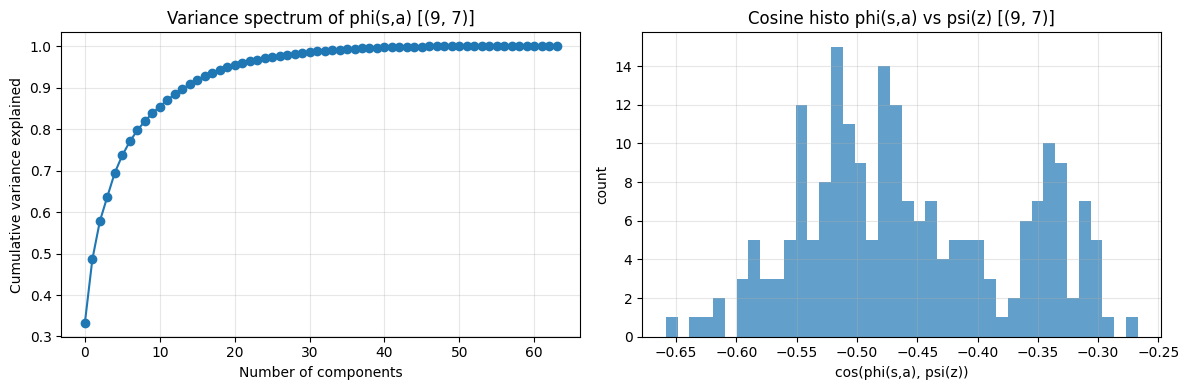

In [5]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_network, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        task_embedding = q_network.encode_goal(torch.tensor(goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy()
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_network, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

## HTML visualisation

In [6]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])

(9, 9)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(7, 7)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(3, 5)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(3, 9)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(5, 5)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
plots/full_embedding_dashboard_maze.html
{'trace': 0.32345949650316963, 'mean_diag': 0.0050540546328620255, 'mean_abs_offdiag': 0.0008548575988311792, 'eig_ratio': 757149.6827690877, 'mean_pairwise_cos': 0.0050820824690163136}
